# Company Default Prediction using Logistic Regression

## Project Overview
This notebook analyzes company financial ratios and builds predictive models to estimate the probability of company default. The workflow includes data cleaning, outlier treatment, multicollinearity checks, Logistic Regression, Linear Discriminant Analysis, and Random Forest benchmarking.

**Dataset:** `CompanyDefault.csv`  
**Target variable:** `default`  
**Objective:** Predict whether a company is likely to default based on financial indicators.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [2]:
DATA_PATH = "CompanyDefault.csv"
Default = pd.read_csv(DATA_PATH)
Default.head()

,Num,Default,Total_assets,Total_income,PAT_as_%_of_total_income,PBDITA_as_%_of_total_income,PBT_as_%_of_total_income,Cash_profit_as_%_of_total_income,Current_ratio,Debt_to_equity_ratio
0,1,1,210.5,125.3,-25.059856,-10.454908,-25.059856,-19.792498,0.86,2.99
1,2,1,674.4,939.6,-5.487016,-0.723712,-5.487016,-4.252448,0.87,48.74
2,3,1,288.3,1.2,-2233.333333,-1785.083333,-2175.000000,-2100.000000,1.40,0.28
3,4,1,32.2,30.3,-15.511551,-6.930693,-15.181518,-12.541254,0.44,24.50
4,5,1,380.9,24.6,-208.943089,-1.626016,-208.536585,-142.276423,1.17,10.37


## 3. Basic Dataset Inspection

In [3]:
print("Rows:", Default.shape[0])
print("Columns:", Default.shape[1])
print("Column names:")
print(Default.columns.tolist())

Rows: 1384
Columns: 10
Column names:
['Num', 'Default', 'Total_assets', 'Total_income', 'PAT_as_%_of_total_income', 'PBDITA_as_%_of_total_income', 'PBT_as_%_of_total_income', 'Cash_profit_as_%_of_total_income', 'Current_ratio', 'Debt_to_equity_ratio']


In [4]:
Default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384 entries, 0 to 1383
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Num                               1384 non-null   int64  
 1   Default                           1384 non-null   int64  
 2   Total_assets                      1384 non-null   float64
 3   Total_income                      1384 non-null   float64
 4   PAT_as_%_of_total_income          1384 non-null   float64
 5   PBDITA_as_%_of_total_income       1384 non-null   float64
 6   PBT_as_%_of_total_income          1384 non-null   float64
 7   Cash_profit_as_%_of_total_income  1384 non-null   float64
 8   Current_ratio                     1384 non-null   float64
 9   Debt_to_equity_ratio              1384 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 108.3 KB


In [5]:
print("Duplicate rows:", Default.duplicated().sum())
print("Missing values:")
print(Default.isnull().sum())

Duplicate rows: 0
Missing values:
Num                                 0
Default                             0
Total_assets                        0
Total_income                        0
PAT_as_%_of_total_income            0
PBDITA_as_%_of_total_income         0
PBT_as_%_of_total_income            0
Cash_profit_as_%_of_total_income    0
Current_ratio                       0
Debt_to_equity_ratio                0
dtype: int64


## 4. Data Cleaning

In [6]:
Default.columns = (
    Default.columns
    .str.strip()
    .str.replace('as_%_of', 'to', regex=False)
    .str.replace('%', 'perc', regex=False)
    .str.replace(' ', '_', regex=False)
)

Default = Default.rename(columns={'Default': 'default'})
Default = Default.drop(columns=['Num'], errors='ignore')
Default.head()

,default,Total_assets,Total_income,PAT_to_total_income,PBDITA_to_total_income,PBT_to_total_income,Cash_profit_to_total_income,Current_ratio,Debt_to_equity_ratio
0,1,210.5,125.3,-25.059856,-10.454908,-25.059856,-19.792498,0.86,2.99
1,1,674.4,939.6,-5.487016,-0.723712,-5.487016,-4.252448,0.87,48.74
2,1,288.3,1.2,-2233.333333,-1785.083333,-2175.000000,-2100.000000,1.40,0.28
3,1,32.2,30.3,-15.511551,-6.930693,-15.181518,-12.541254,0.44,24.50
4,1,380.9,24.6,-208.943089,-1.626016,-208.536585,-142.276423,1.17,10.37


## 5. Descriptive Statistics and Target Distribution

In [7]:
Default.describe().T

,count,mean,std,min,25%,50%,75%,max
default,1384.0,0.234104,0.423591,0.0,0.000000,0.000000,0.000000,1.0000
Total_assets,1384.0,256.762568,404.127921,0.5,25.800000,103.450000,296.825000,2275.9710
Total_income,1384.0,381.657131,583.461117,0.1,31.225000,187.550000,428.142581,3449.8260
PAT_to_total_income,1384.0,-29.922088,346.245121,-9700.0,0.000000,1.464327,4.075183,150.0000
PBDITA_to_total_income,1384.0,-4.380180,218.854784,-6400.0,3.501816,8.569963,13.438735,100.0000
PBT_to_total_income,1384.0,-27.554086,332.137949,-9700.0,0.000000,2.148565,5.345512,100.0000
Cash_profit_to_total_income,1384.0,-16.239313,245.587280,-6400.0,1.045456,4.638115,8.024023,100.0000
Current_ratio,1384.0,1.771303,2.323773,0.0,0.880000,1.230000,1.942500,18.7900
Debt_to_equity_ratio,1384.0,3.394933,11.364884,0.0,0.187500,0.860000,1.970000,90.9441


In [8]:
target_counts = Default['default'].value_counts().sort_index()
target_percentage = Default['default'].value_counts(normalize=True).sort_index() * 100
summary = pd.DataFrame({'count': target_counts, 'percentage': target_percentage.round(2)})
summary.index = ['Non-Default (0)', 'Default (1)']
summary

,count,percentage
Non-Default (0),1060,76.59
Default (1),324,23.41


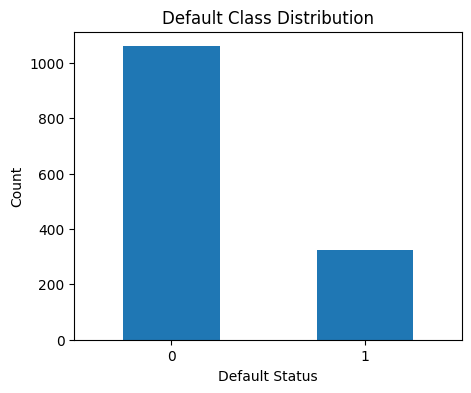

In [9]:
plt.figure(figsize=(5,4))
Default['default'].value_counts().sort_index().plot(kind='bar')
plt.title('Default Class Distribution')
plt.xlabel('Default Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 6. Outlier Treatment

Financial ratio data often contains extreme values. The notebook caps outliers using the IQR method instead of deleting rows, so all company records are retained.

In [10]:
X_raw = Default.drop(columns='default')
y = Default['default']

X_capped = X_raw.copy()
for column in X_capped.columns:
    q1, q3 = np.percentile(X_capped[column], [25, 75])
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    X_capped[column] = X_capped[column].clip(lower_limit, upper_limit)

Default_clean = pd.concat([X_capped, y], axis=1)
Default_clean.head()

,Total_assets,Total_income,PAT_to_total_income,PBDITA_to_total_income,PBT_to_total_income,Cash_profit_to_total_income,Current_ratio,Debt_to_equity_ratio,default
0,210.5,125.3,-6.112774,-10.454908,-8.018268,-9.422395,0.86,2.99000,1
1,674.4,939.6,-5.487016,-0.723712,-5.487016,-4.252448,0.87,4.64375,1
2,288.3,1.2,-6.112774,-11.403562,-8.018268,-9.422395,1.40,0.28000,1
3,32.2,30.3,-6.112774,-6.930693,-8.018268,-9.422395,0.44,4.64375,1
4,380.9,24.6,-6.112774,-1.626016,-8.018268,-9.422395,1.17,4.64375,1


## 7. Correlation Analysis

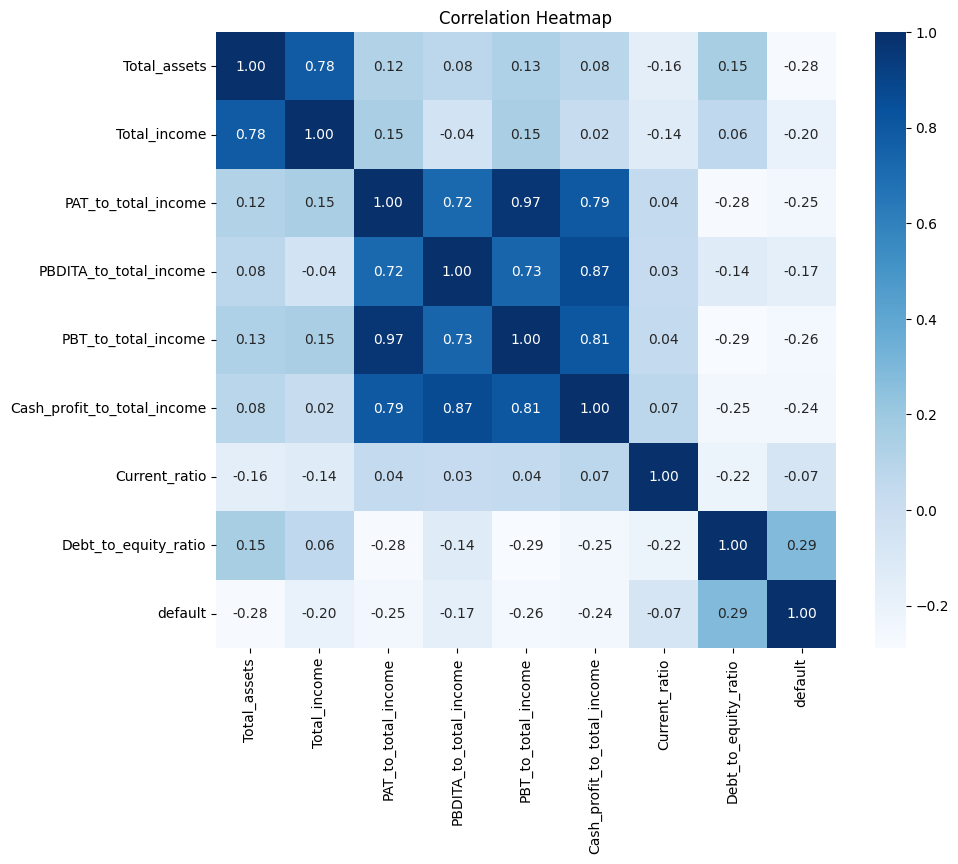

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(Default_clean.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 8. Multicollinearity Check using VIF

Highly correlated variables can make Logistic Regression coefficients unstable. VIF is used to identify and remove highly collinear variables.

In [12]:
def calculate_vif(X):
    vif = pd.DataFrame()
    vif['variable'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif.sort_values(by='VIF', ascending=False)

X_vif = Default_clean.drop(columns='default')
calculate_vif(X_vif)

,variable,VIF
4,PBT_to_total_income,21.102170
2,PAT_to_total_income,19.296923
5,Cash_profit_to_total_income,7.997149
3,PBDITA_to_total_income,7.834539
0,Total_assets,5.199503
1,Total_income,5.155808
6,Current_ratio,1.983593
7,Debt_to_equity_ratio,1.857565


In [13]:
# Remove variables with high multicollinearity based on VIF and correlation analysis
columns_to_drop = ['PBT_to_total_income', 'Cash_profit_to_total_income', 'Total_assets']
X_model = X_vif.drop(columns=columns_to_drop)
calculate_vif(X_model)

,variable,VIF
2,PBDITA_to_total_income,3.664134
1,PAT_to_total_income,2.758106
3,Current_ratio,1.955957
4,Debt_to_equity_ratio,1.757982
0,Total_income,1.697737


## 9. Train-Test Split

In [14]:
y = Default_clean['default']
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.30, random_state=12, stratify=y
)

Default_train = pd.concat([X_train, y_train], axis=1)
Default_test = pd.concat([X_test, y_test], axis=1)

print("Training shape:", Default_train.shape)
print("Testing shape:", Default_test.shape)
print("Train target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("Test target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training shape: (968, 6)
Testing shape: (416, 6)
Train target distribution:
default
0    0.765
1    0.235
Name: proportion, dtype: float64
Test target distribution:
default
0    0.767
1    0.233
Name: proportion, dtype: float64


## 10. Logistic Regression Model

The final Logistic Regression model uses selected variables after reducing multicollinearity.

In [15]:
formula = 'default ~ PBDITA_to_total_income + Debt_to_equity_ratio + Total_income'
logit_model = smf.logit(formula=formula, data=Default_train).fit()
logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.463925
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                  968
Model:                          Logit   Df Residuals:                      964
Method:                           MLE   Df Model:                            3
Date:                Sat, 20 Jun 2026   Pseudo R-squ.:                  0.1482
Time:                        11:21:43   Log-Likelihood:                -449.08
converged:                       True   LL-Null:                       -527.23
Covariance Type:            nonrobust   LLR p-value:                 1.149e-33
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1.0287      0.148     -6.960      0.000      -1.318      -0.739
PBDITA_to_total_income    -0.0396      0.009     -4.569      0.000      -0.057      -0.023
Debt_to_equity_ratio       0.4355      0.050      8.691      0.000       0.337       0.534
Total_income              -0.0022      0.000     -6.463      0.000      -0.003      -0.002
==========================================================================================
"""

## 11. Logistic Regression Evaluation

In [16]:
train_prob = logit_model.predict(Default_train)
test_prob = logit_model.predict(Default_test)

# Default threshold evaluation
train_pred_50 = (train_prob >= 0.50).astype(int)
test_pred_50 = (test_prob >= 0.50).astype(int)

print("Train Accuracy at 0.50 threshold:", round(accuracy_score(y_train, train_pred_50), 4))
print("Test Accuracy at 0.50 threshold:", round(accuracy_score(y_test, test_pred_50), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, test_prob), 4))
print("\nClassification Report - Test Set at 0.50 threshold")
print(classification_report(y_test, test_pred_50, digits=3))

Train Accuracy at 0.50 threshold: 0.811
Test Accuracy at 0.50 threshold: 0.8005
Test ROC-AUC: 0.6938

Classification Report - Test Set at 0.50 threshold
              precision    recall  f1-score   support

           0      0.811     0.966     0.881       319
           1      0.694     0.258     0.376        97

    accuracy                          0.800       416
   macro avg      0.752     0.612     0.629       416
weighted avg      0.783     0.800     0.763       416



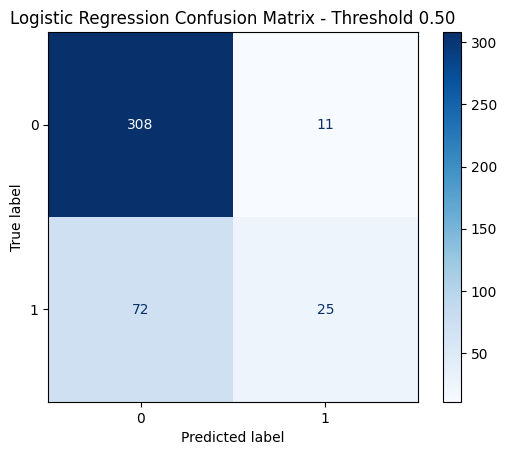

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred_50, cmap='Blues')
plt.title('Logistic Regression Confusion Matrix - Threshold 0.50')
plt.show()

## 12. Threshold Optimization

Since default cases are fewer than non-default cases, the default threshold of 0.50 may miss many default companies. The threshold is adjusted using the ROC curve and Youden's J statistic.

In [18]:
fpr, tpr, thresholds = roc_curve(y_train, train_prob)
optimal_index = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_index]
print("Optimal threshold:", round(optimal_threshold, 4))

train_pred_opt = (train_prob >= optimal_threshold).astype(int)
test_pred_opt = (test_prob >= optimal_threshold).astype(int)

print("Train Accuracy at optimal threshold:", round(accuracy_score(y_train, train_pred_opt), 4))
print("Test Accuracy at optimal threshold:", round(accuracy_score(y_test, test_pred_opt), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, test_prob), 4))
print("\nClassification Report - Test Set at optimal threshold")
print(classification_report(y_test, test_pred_opt, digits=3))

Optimal threshold: 0.2622
Train Accuracy at optimal threshold: 0.7438
Test Accuracy at optimal threshold: 0.7596
Test ROC-AUC: 0.6938

Classification Report - Test Set at optimal threshold
              precision    recall  f1-score   support

           0      0.859     0.821     0.840       319
           1      0.486     0.557     0.519        97

    accuracy                          0.760       416
   macro avg      0.673     0.689     0.679       416
weighted avg      0.772     0.760     0.765       416



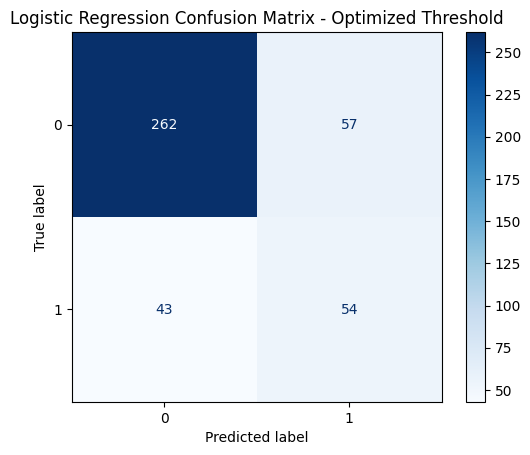

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, test_pred_opt, cmap='Blues')
plt.title('Logistic Regression Confusion Matrix - Optimized Threshold')
plt.show()

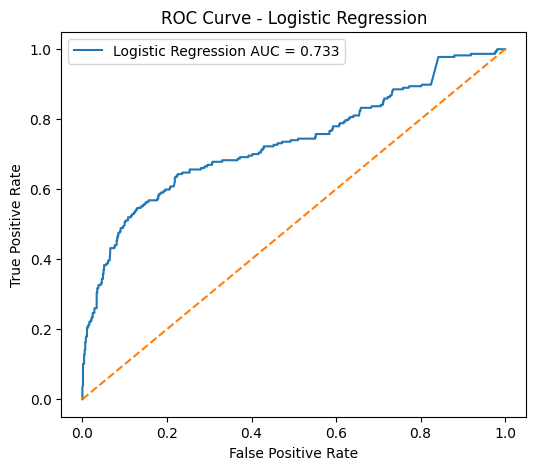

In [20]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression AUC = {roc_auc_score(y_train, train_prob):.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

## 13. Linear Discriminant Analysis Benchmark

In [21]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

lda_train_prob = lda_model.predict_proba(X_train)[:, 1]
lda_test_prob = lda_model.predict_proba(X_test)[:, 1]
lda_test_pred = lda_model.predict(X_test)

print("LDA Test Accuracy:", round(accuracy_score(y_test, lda_test_pred), 4))
print("LDA Test ROC-AUC:", round(roc_auc_score(y_test, lda_test_prob), 4))
print("\nClassification Report - LDA Test Set")
print(classification_report(y_test, lda_test_pred, digits=3))

LDA Test Accuracy: 0.7957
LDA Test ROC-AUC: 0.6751

Classification Report - LDA Test Set
              precision    recall  f1-score   support

           0      0.811     0.956     0.878       319
           1      0.650     0.268     0.380        97

    accuracy                          0.796       416
   macro avg      0.731     0.612     0.629       416
weighted avg      0.774     0.796     0.762       416



## 14. Random Forest Benchmark

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=12,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

rf_test_prob = rf_model.predict_proba(X_test)[:, 1]
rf_test_pred = rf_model.predict(X_test)

print("Random Forest Test Accuracy:", round(accuracy_score(y_test, rf_test_pred), 4))
print("Random Forest Test ROC-AUC:", round(roc_auc_score(y_test, rf_test_prob), 4))
print("\nClassification Report - Random Forest Test Set")
print(classification_report(y_test, rf_test_pred, digits=3))

Random Forest Test Accuracy: 0.8389
Random Forest Test ROC-AUC: 0.8957

Classification Report - Random Forest Test Set
              precision    recall  f1-score   support

           0      0.926     0.859     0.891       319
           1      0.625     0.773     0.691        97

    accuracy                          0.839       416
   macro avg      0.775     0.816     0.791       416
weighted avg      0.856     0.839     0.844       416



In [23]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)
feature_importance

,feature,importance
4,Debt_to_equity_ratio,0.307343
1,PAT_to_total_income,0.224019
0,Total_income,0.206743
2,PBDITA_to_total_income,0.140341
3,Current_ratio,0.121553


## 15. Model Comparison

In [24]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression 0.50 Threshold', 'Logistic Regression Optimized Threshold', 'LDA', 'Random Forest'],
    'Test Accuracy': [
        accuracy_score(y_test, test_pred_50),
        accuracy_score(y_test, test_pred_opt),
        accuracy_score(y_test, lda_test_pred),
        accuracy_score(y_test, rf_test_pred)
    ],
    'Test ROC-AUC': [
        roc_auc_score(y_test, test_prob),
        roc_auc_score(y_test, test_prob),
        roc_auc_score(y_test, lda_test_prob),
        roc_auc_score(y_test, rf_test_prob)
    ]
})
comparison.round(4)

,Model,Test Accuracy,Test ROC-AUC
0,Logistic Regression 0.50 Threshold,0.8005,0.6938
1,Logistic Regression Optimized Threshold,0.7596,0.6938
2,LDA,0.7957,0.6751
3,Random Forest,0.8389,0.8957


## 16. Observations

- The dataset contains **1,384 company records** and financial variables related to assets, income, profitability ratios, liquidity, and leverage.
- There are no missing values in the dataset.
- The dataset is imbalanced: non-default companies are the majority, while default companies form a smaller share.
- Profitability-related ratio variables are highly correlated with each other, so VIF-based variable reduction was required before building the final Logistic Regression model.
- Logistic Regression provides an interpretable model for estimating probability of default.
- The default 0.50 threshold gives higher overall accuracy but lower ability to detect default companies.
- The optimized threshold improves the detection of default companies, which is more useful for credit-risk analysis.
- Random Forest is useful as a benchmark model, but Logistic Regression is easier to interpret for business and credit-risk decision-making.

## 17. Conclusion

The analysis shows that company default prediction can be performed using financial indicators such as profitability, debt-to-equity ratio, and total income. Logistic Regression is a suitable model for this problem because it provides both prediction and interpretability.

For credit-risk use cases, the objective is usually not only to maximize accuracy but also to identify companies with higher default risk. Therefore, threshold optimization is important. The optimized Logistic Regression model gives a better balance between identifying default and non-default companies.

Overall, this project demonstrates a complete predictive modeling workflow: data cleaning, outlier handling, multicollinearity treatment, model building, model evaluation, threshold adjustment, and business interpretation.